<a href="https://colab.research.google.com/github/carolineb3/Earnings-Call-NLP-Pipeline/blob/main/notebooks/04_lm_dictionary_sentiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Step 4: Loughran-McDonald Dictionary Sentiment

This notebook adds finance-specific dictionary sentiment features to the earnings call data. It uses the Loughran-McDonald dictionary to measure positive, negative, uncertainty, and litigious language in both prepared remarks and Q&A.

Note: this step scores the raw transcript sections, not the cleaned `_clean` columns from Step 3. The cleaned text is useful for topic modeling, but we decided that dictionary matching is better when preserving the original word forms.

## What this notebook does

- Reads `584_earnings_nlp.parquet` from Step 3.
- Loads the Loughran-McDonald financial dictionary.
- Builds word lists for positive, negative, uncertainty, and litigious language.
- Scores prepared remarks and Q&A separately.
- Creates net sentiment as positive score minus negative score.
- Saves the result as `584_earnings_sentiment.parquet`.

## Output

- `584_earnings_sentiment.parquet`

New columns added include:

- `prep_positive_score`
- `prep_negative_score`
- `prep_uncertainty_score`
- `prep_litigious_score`
- `prep_net_sentiment`
- `qa_positive_score`
- `qa_negative_score`
- `qa_uncertainty_score`
- `qa_litigious_score`
- `qa_net_sentiment`

## Checks in this notebook

- Prints dictionary word counts.
- Prints summary statistics for the sentiment features.
- Shows sample scored rows.
- Runs exploratory checks comparing prepared remarks, Q&A tone, and return labels.

In [ ]:
# =============================================================================
# STEP 4 — Loughran-McDonald Sentiment
# Score raw prepared remarks and Q&A text with the LM financial dictionary, then
# save the sentiment features for the next notebook.
# =============================================================================

!pip install pyspark nltk -q

from google.colab import drive
drive.mount('/content/drive')

import nltk
nltk.download('punkt',     quiet=True)
nltk.download('punkt_tab', quiet=True)

import pandas as pd
import re

BASE_DIR    = "/content/drive/MyDrive/MIS_584_Project"
PARQUET_IN  = f"{BASE_DIR}/Parquet/584_earnings_nlp"
PARQUET_OUT = f"{BASE_DIR}/Parquet/584_earnings_sentiment"
LM_CSV      = f"{BASE_DIR}/LoughranMcDonald_MasterDictionary_1993-2024.csv"

# ── Load the LM dictionary ────────────────────────────────────────────────────────
print("Loading Loughran-McDonald dictionary...")
lm_df = pd.read_csv(LM_CSV)
print(f"LM dictionary rows: {len(lm_df):,}")

negative_words    = set(lm_df[lm_df['Negative']    != 0]['Word'].str.lower())
positive_words    = set(lm_df[lm_df['Positive']    != 0]['Word'].str.lower())
uncertainty_words = set(lm_df[lm_df['Uncertainty'] != 0]['Word'].str.lower())
litigious_words   = set(lm_df[lm_df['Litigious']   != 0]['Word'].str.lower())

print(f"Negative words    : {len(negative_words):,}")
print(f"Positive words    : {len(positive_words):,}")
print(f"Uncertainty words : {len(uncertainty_words):,}")
print(f"Litigious words   : {len(litigious_words):,}")

def lm_score(text):
    """Return LM positive, negative, uncertainty, and litigious scores."""
    if not text or not isinstance(text, str):
        return 0.0, 0.0, 0.0, 0.0

    tokens = re.findall(r"[A-Za-z]+", text.lower())
    total = max(len(tokens), 1)

    pos = sum(1 for t in tokens if t in positive_words) / total
    neg = sum(1 for t in tokens if t in negative_words) / total
    unc = sum(1 for t in tokens if t in uncertainty_words) / total
    lit = sum(1 for t in tokens if t in litigious_words) / total

    return pos, neg, unc, lit

import os
os.environ['PYSPARK_SUBMIT_ARGS'] = '--driver-memory 8g pyspark-shell'

from pyspark.sql import SparkSession

# Start a fresh Spark session for this notebook
_active = SparkSession.getActiveSession()
if _active is not None:
    _active.stop()

spark = SparkSession.builder \
    .master("local") \
    .appName("584_LM_Sentiment") \
    .config("spark.driver.maxResultSize", "0") \
    .getOrCreate()

sc = spark.sparkContext
print(f"Spark version: {spark.version}")

df  = spark.read.parquet(PARQUET_IN)
pdf = df.toPandas()
print(f"Scoring {len(pdf)} transcripts...")

# Dictionary matching uses the original transcript text, not the cleaned LDA text

# ── Score prepared remarks using the raw text ────────────────────────────────
print("\nScoring prepared remarks...")
prep_scores = pdf['prepared_remarks'].apply(lm_score)
pdf['prep_positive_score']    = prep_scores.apply(lambda x: round(x[0], 6))
pdf['prep_negative_score']    = prep_scores.apply(lambda x: round(x[1], 6))
pdf['prep_uncertainty_score'] = prep_scores.apply(lambda x: round(x[2], 6))
pdf['prep_litigious_score']   = prep_scores.apply(lambda x: round(x[3], 6))
pdf['prep_net_sentiment']     = (pdf['prep_positive_score'] - pdf['prep_negative_score']).round(6)

# ── Score Q&A using the raw text ─────────────────────────────────────────────
print("Scoring Q&A sections...")
qa_scores = pdf['qa_section'].apply(lm_score)
pdf['qa_positive_score']    = qa_scores.apply(lambda x: round(x[0], 6))
pdf['qa_negative_score']    = qa_scores.apply(lambda x: round(x[1], 6))
pdf['qa_uncertainty_score'] = qa_scores.apply(lambda x: round(x[2], 6))
pdf['qa_litigious_score']   = qa_scores.apply(lambda x: round(x[3], 6))
pdf['qa_net_sentiment']     = (pdf['qa_positive_score'] - pdf['qa_negative_score']).round(6)

print("\nLM Sentiment Summary:")
lm_cols = [
    'prep_net_sentiment', 'prep_negative_score', 'prep_uncertainty_score', 'prep_litigious_score',
    'qa_net_sentiment',   'qa_negative_score',   'qa_uncertainty_score',   'qa_litigious_score',
]
print(pdf[lm_cols].describe().round(6).to_string())

print("\nSample scores (first 15 rows):")
print(pdf[['ticker', 'quarter', 'prep_net_sentiment', 'qa_net_sentiment',
           'prep_uncertainty_score', 'pct_return_3d', 'return_label']].head(15).to_string(index=False))

for col in ['volume_on_date', 'window_days_used']:
    if col in pdf.columns:
        pdf[col] = pdf[col].astype('int64')

df_sentiment = spark.createDataFrame(pdf)
df_sentiment.write.mode('overwrite').parquet(PARQUET_OUT)
print(f"\nSaved to: {PARQUET_OUT}")
print("Verification rows:", spark.read.parquet(PARQUET_OUT).count())
print("Columns:", spark.read.parquet(PARQUET_OUT).columns)

spark.stop()
print("Spark session stopped.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading Loughran-McDonald dictionary...
LM dictionary rows: 86,553
Negative words    : 2,355
Positive words    : 354
Uncertainty words : 297
Litigious words   : 905
Spark version: 4.0.2
Scoring 7076 transcripts...

Scoring prepared remarks...
Scoring Q&A sections...

LM Sentiment Summary:
       prep_net_sentiment  prep_negative_score  prep_uncertainty_score  prep_litigious_score  qa_net_sentiment  qa_negative_score  qa_uncertainty_score  qa_litigious_score
count         7076.000000          7076.000000             7076.000000           7076.000000       7076.000000        7076.000000           7076.000000         7076.000000
mean             0.014684             0.008171                0.008499              0.001375          0.004935           0.010175              0.009160            0.001032
std              0.009076             0.004152                0.0

In [ ]:
spark = SparkSession.builder \
    .master("local") \
    .appName("584_Check_Sentiment") \
    .getOrCreate()

df_check = spark.read.parquet(f"{BASE_DIR}/Parquet/584_earnings_sentiment")

print("Rows:", df_check.count())
print("Has prep_net_sentiment?", "prep_net_sentiment" in df_check.columns)
print("Has qa_net_sentiment?", "qa_net_sentiment" in df_check.columns)
print("Columns:", df_check.columns)

spark.stop()

Rows: 7076
Has prep_net_sentiment? True
Has qa_net_sentiment? True
Columns: ['ticker', 'earnings_date', 'company_name', 'full_text', 'prepared_remarks', 'prepared_words', 'qa_section', 'qa_words', 'quarter', 'sector', 'source', 'word_count', 'year', 'price_on_date', 'price_3d_later', 'pct_return_3d', 'market_adj_return_3d', 'spy_return_3d', 'volume_on_date', 'window_days_used', 'return_label', 'prepared_remarks_clean', 'qa_section_clean', 'prepared_token_count', 'qa_token_count', 'prep_positive_score', 'prep_negative_score', 'prep_uncertainty_score', 'prep_litigious_score', 'prep_net_sentiment', 'qa_positive_score', 'qa_negative_score', 'qa_uncertainty_score', 'qa_litigious_score', 'qa_net_sentiment']


## Exploratory checks

After saving the sentiment checkpoint, the rest of this notebook does a few quick checks on the LM features. Helps show whether dictionary sentiment captures useful differences between prepared remarks, Q&A, and return labels.

In [ ]:
import scipy.stats as stats

# Perform a paired t-test between prepared remarks net sentiment and Q&A net sentiment
t_statistic_paired, p_value_paired = stats.ttest_rel(pdf['prep_net_sentiment'], pdf['qa_net_sentiment'])

print(f"Paired T-statistic (Prepared vs. Q&A Net Sentiment): {t_statistic_paired:.4f}")
print(f"P-value (paired t-test): {p_value_paired:.4f}")

if p_value_paired < 0.05:
    print("There is a statistically significant difference in mean sentiment between prepared remarks and Q&A sections (at alpha=0.05).")
else:
    print("There is no statistically significant difference in mean sentiment between prepared remarks and Q&A sections (at alpha=0.05).")

print(f"\nMean Prepared Remarks Net Sentiment: {pdf['prep_net_sentiment'].mean():.4f}")
print(f"Mean Q&A Net Sentiment: {pdf['qa_net_sentiment'].mean():.4f}")

Paired T-statistic (Prepared vs. Q&A Net Sentiment): 94.3811
P-value (paired t-test): 0.0000
There is a statistically significant difference in mean sentiment between prepared remarks and Q&A sections (at alpha=0.05).

Mean Prepared Remarks Net Sentiment: 0.0147
Mean Q&A Net Sentiment: 0.0049


In [ ]:
import scipy.stats as stats

correlation_prep_qa, p_value_prep_qa = stats.pearsonr(pdf['prep_net_sentiment'], pdf['qa_net_sentiment'])

print(f"Pearson Correlation (Prepared vs. Q&A Net Sentiment): {correlation_prep_qa:.4f}")
print(f"P-value: {p_value_prep_qa:.4f}")

if p_value_prep_qa < 0.05:
    print("The correlation between Prepared Remarks and Q&A Net Sentiment is statistically significant at the 0.05 level.")
else:
    print("The correlation between Prepared Remarks and Q&A Net Sentiment is not statistically significant at the 0.05 level.")

Pearson Correlation (Prepared vs. Q&A Net Sentiment): 0.3657
P-value: 0.0000
The correlation between Prepared Remarks and Q&A Net Sentiment is statistically significant at the 0.05 level.


In [ ]:
import scipy.stats as stats

# Filter for positive and negative return labels for Q&A net sentiment
positive_qa_sentiment = pdf[pdf['return_label'] == 'positive']['qa_net_sentiment']
negative_qa_sentiment = pdf[pdf['return_label'] == 'negative']['qa_net_sentiment']

# Perform independent samples t-test
t_statistic_qa, p_value_ttest_qa = stats.ttest_ind(positive_qa_sentiment, negative_qa_sentiment)

print(f"Q&A Section T-statistic: {t_statistic_qa:.4f}")
print(f"Q&A Section P-value (t-test): {p_value_ttest_qa:.4f}")

if p_value_ttest_qa < 0.05:
    print("There is a statistically significant difference in mean Q&A sentiment between positive and negative return labels (at alpha=0.05).")
else:
    print("There is no statistically significant difference in mean Q&A sentiment between positive and negative return labels (at alpha=0.05).")

print(f"\nMean Q&A sentiment for 'positive' returns: {positive_qa_sentiment.mean():.4f}")
print(f"Mean Q&A sentiment for 'negative' returns: {negative_qa_sentiment.mean():.4f}")

Q&A Section T-statistic: 1.7783
Q&A Section P-value (t-test): 0.0754
There is no statistically significant difference in mean Q&A sentiment between positive and negative return labels (at alpha=0.05).

Mean Q&A sentiment for 'positive' returns: 0.0050
Mean Q&A sentiment for 'negative' returns: 0.0048


In [ ]:
correlation = pdf['prep_net_sentiment'].corr(pdf['pct_return_3d'])
print(f"Correlation between Prepared Remarks Net Sentiment and 3-Day Percentage Return: {correlation:.4f}")

Correlation between Prepared Remarks Net Sentiment and 3-Day Percentage Return: -0.0016


In [ ]:
import scipy.stats as stats

correlation_pearson, p_value = stats.pearsonr(pdf['prep_net_sentiment'], pdf['pct_return_3d'])

print(f"Pearson Correlation Coefficient: {correlation_pearson:.4f}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("The correlation is statistically significant at the 0.05 level.")
else:
    print("The correlation is not statistically significant at the 0.05 level.")

Pearson Correlation Coefficient: -0.0016
P-value: 0.8956
The correlation is not statistically significant at the 0.05 level.


In [ ]:
import scipy.stats as stats

# Filter for positive and negative return labels
positive_sentiment = pdf[pdf['return_label'] == 'positive']['prep_net_sentiment']
negative_sentiment = pdf[pdf['return_label'] == 'negative']['prep_net_sentiment']

# Perform independent samples t-test
t_statistic, p_value_ttest = stats.ttest_ind(positive_sentiment, negative_sentiment)

print(f"T-statistic: {t_statistic:.4f}")
print(f"P-value (t-test): {p_value_ttest:.4f}")

if p_value_ttest < 0.05:
    print("There is a statistically significant difference in mean sentiment between positive and negative return labels (at alpha=0.05).")
else:
    print("There is no statistically significant difference in mean sentiment between positive and negative return labels (at alpha=0.05).")

print(f"\nMean sentiment for 'positive' returns: {positive_sentiment.mean():.4f}")
print(f"Mean sentiment for 'negative' returns: {negative_sentiment.mean():.4f}")

T-statistic: -0.4290
P-value (t-test): 0.6679
There is no statistically significant difference in mean sentiment between positive and negative return labels (at alpha=0.05).

Mean sentiment for 'positive' returns: 0.0146
Mean sentiment for 'negative' returns: 0.0147


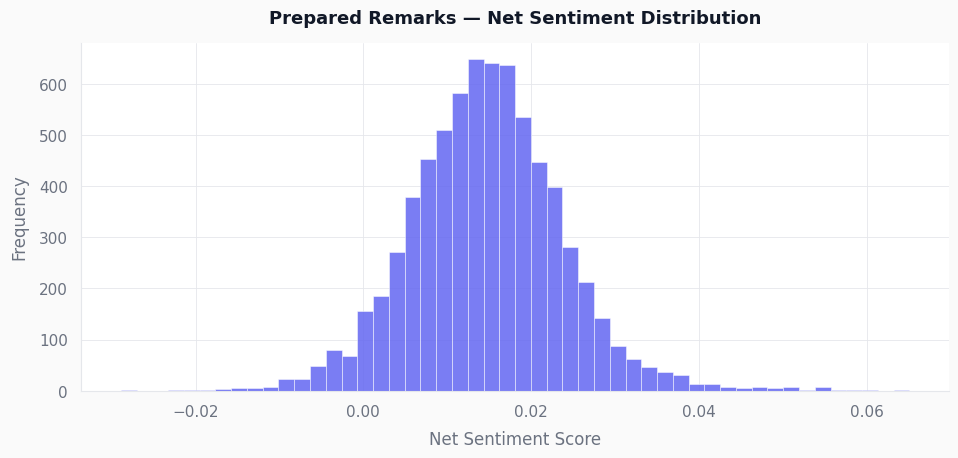

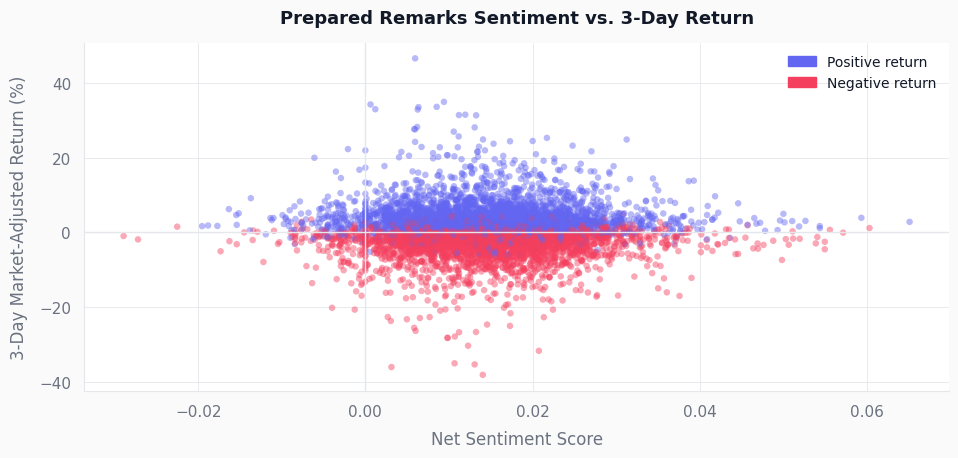

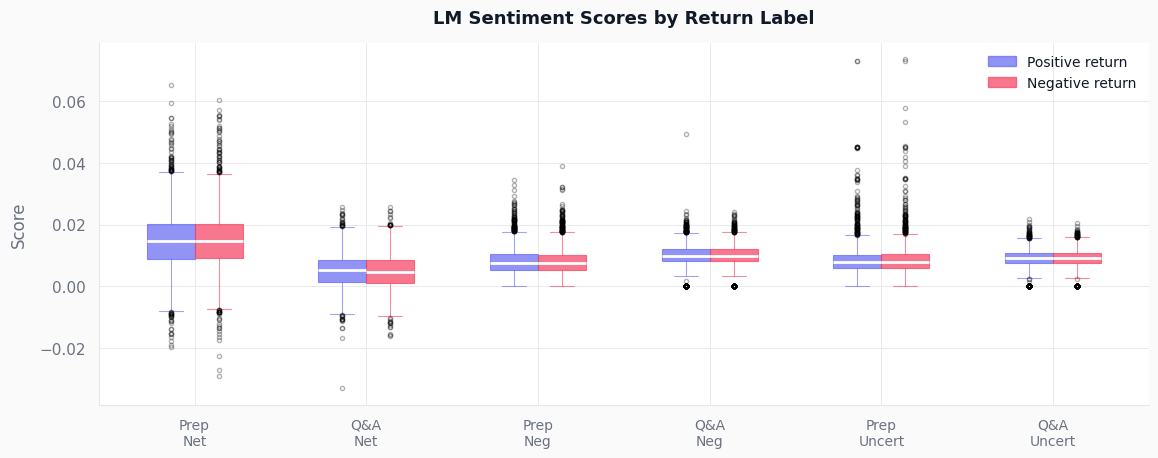

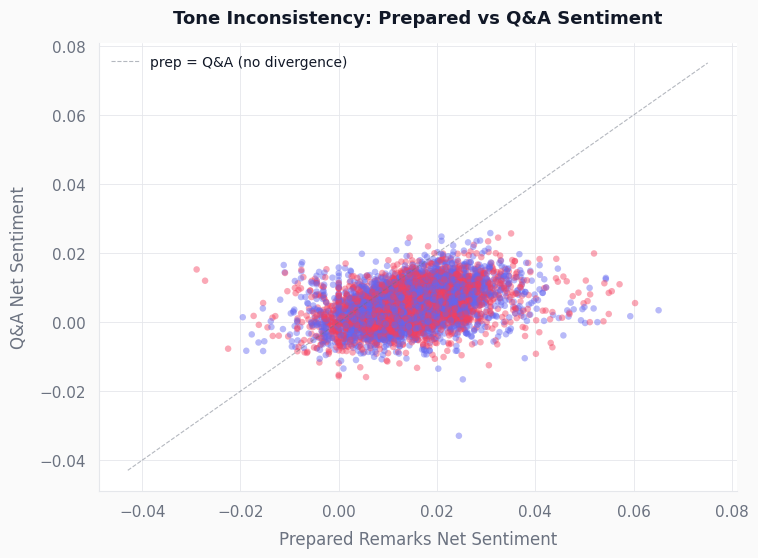

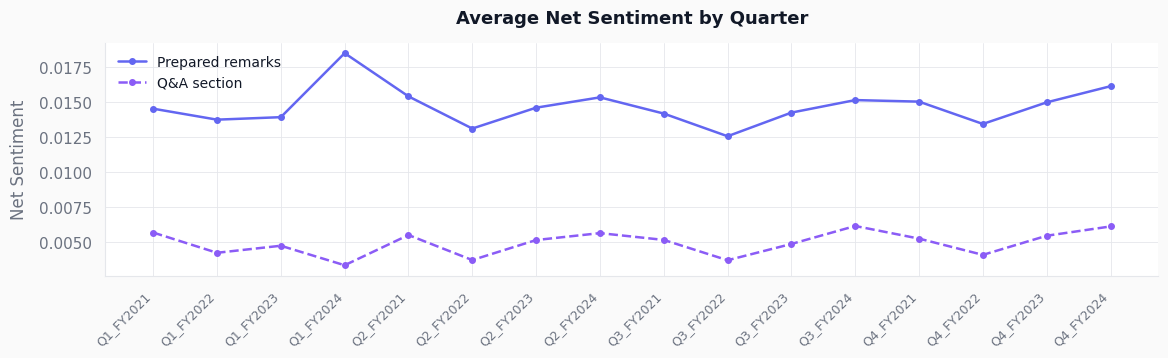

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Plot styling ──────────────────────────────────────────────────────────────
BACKGROUND  = '#FAFAFA'
CARD_FACE   = '#FFFFFF'
BORDER      = '#E5E7EB'
TEXT_MAIN   = '#111827'
TEXT_MUTED  = '#6B7280'
BLUE        = '#6366F1'
PURPLE      = '#8B5CF6'
POS_COLOR   = '#6366F1'
NEG_COLOR   = '#F43F5E'

plt.rcParams.update({
    'figure.facecolor':  BACKGROUND,
    'axes.facecolor':    CARD_FACE,
    'axes.edgecolor':    BORDER,
    'axes.linewidth':    0.8,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'grid.color':        BORDER,
    'grid.linewidth':    0.6,
    'grid.linestyle':    '-',
    'text.color':        TEXT_MAIN,
    'axes.labelcolor':   TEXT_MUTED,
    'xtick.color':       TEXT_MUTED,
    'ytick.color':       TEXT_MUTED,
    'font.family':       'sans-serif',
    'font.size':         11,
    'axes.titlesize':    13,
    'axes.titleweight':  'bold',
    'axes.titlepad':     14,
    'axes.labelpad':     8,
})

def card_fig(w=10, h=5):
    fig, ax = plt.subplots(figsize=(w, h))
    fig.patch.set_facecolor(BACKGROUND)
    ax.set_facecolor(CARD_FACE)
    for spine in ax.spines.values():
        spine.set_edgecolor(BORDER)
        spine.set_linewidth(0.8)
    return fig, ax


# ── 1. Sentiment distribution ─────────────────────────────────────────────────
fig, ax = card_fig(10, 5)
ax.hist(pdf['prep_net_sentiment'], bins=50, color=BLUE, alpha=0.85,
        edgecolor='white', linewidth=0.4)
ax.set_title('Prepared Remarks — Net Sentiment Distribution')
ax.set_xlabel('Net Sentiment Score')
ax.set_ylabel('Frequency')
plt.tight_layout(pad=2)
plt.show()


# ── 2. Sentiment vs market-adjusted return ────────────────────────────────────
fig, ax = card_fig(10, 5)
colors = pdf['return_label'].map({'positive': POS_COLOR, 'negative': NEG_COLOR})
ax.scatter(pdf['prep_net_sentiment'], pdf['market_adj_return_3d'],
           c=colors, alpha=0.45, s=22, linewidths=0)
ax.axhline(0, color=BORDER, linewidth=1)
ax.axvline(0, color=BORDER, linewidth=1)
ax.set_title('Prepared Remarks Sentiment vs. 3-Day Market-Adjusted Return')
ax.set_xlabel('Net Sentiment Score')
ax.set_ylabel('3-Day Market-Adjusted Return (%)')
legend_handles = [
    mpatches.Patch(color=POS_COLOR, label='Positive return'),
    mpatches.Patch(color=NEG_COLOR, label='Negative return'),
]
ax.legend(handles=legend_handles, frameon=False, fontsize=10)
plt.tight_layout(pad=2)
plt.show()


# ── 3. Box plots — LM scores by return label ──────────────────────────────────
lm_cols = [
    'prep_net_sentiment', 'qa_net_sentiment',
    'prep_negative_score', 'qa_negative_score',
    'prep_uncertainty_score', 'qa_uncertainty_score',
]
labels_clean = [
    'Prep\nNet', 'Q&A\nNet',
    'Prep\nNeg', 'Q&A\nNeg',
    'Prep\nUncert', 'Q&A\nUncert',
]

fig, ax = card_fig(12, 5)
pos_data = [pdf[pdf['return_label'] == 'positive'][c].dropna().values for c in lm_cols]
neg_data = [pdf[pdf['return_label'] == 'negative'][c].dropna().values for c in lm_cols]

x = np.arange(len(lm_cols))
w = 0.28

def styled_box(ax, data, positions, color):
    bp = ax.boxplot(data, positions=positions, widths=w, patch_artist=True,
                    manage_ticks=False,
                    boxprops=dict(facecolor=color, alpha=0.7, linewidth=0.8, color=color),
                    medianprops=dict(color='white', linewidth=2),
                    whiskerprops=dict(color=color, linewidth=0.8, alpha=0.6),
                    capprops=dict(color=color, linewidth=0.8, alpha=0.6),
                    flierprops=dict(marker='o', color=color, alpha=0.3,
                                    markersize=3, linewidth=0))
    return bp

styled_box(ax, pos_data, x - w/2, POS_COLOR)
styled_box(ax, neg_data, x + w/2, NEG_COLOR)

ax.set_xticks(x)
ax.set_xticklabels(labels_clean, fontsize=10)
ax.set_title('LM Sentiment Scores by Return Label')
ax.set_ylabel('Score')
legend_handles = [
    mpatches.Patch(color=POS_COLOR, alpha=0.7, label='Positive return'),
    mpatches.Patch(color=NEG_COLOR, alpha=0.7, label='Negative return'),
]
ax.legend(handles=legend_handles, frameon=False, fontsize=10)
plt.tight_layout(pad=2)
plt.show()


# ── 4. Tone inconsistency — prep vs Q&A sentiment ────────────────────────────
fig, ax = card_fig(8, 6)
ax.scatter(pdf['prep_net_sentiment'], pdf['qa_net_sentiment'],
           c=colors, alpha=0.45, s=22, linewidths=0)
lim_min = min(pdf['prep_net_sentiment'].min(), pdf['qa_net_sentiment'].min()) - 0.01
lim_max = max(pdf['prep_net_sentiment'].max(), pdf['qa_net_sentiment'].max()) + 0.01
ax.plot([lim_min, lim_max], [lim_min, lim_max],
        color=TEXT_MUTED, linewidth=0.8, linestyle='--', alpha=0.5,
        label='prep = Q&A (no divergence)')
ax.set_title('Tone Inconsistency: Prepared vs Q&A Sentiment')
ax.set_xlabel('Prepared Remarks Net Sentiment')
ax.set_ylabel('Q&A Net Sentiment')
ax.legend(frameon=False, fontsize=10)
plt.tight_layout(pad=2)
plt.show()


# ── 5. Quarterly sentiment trend ──────────────────────────────────────────────
fig, ax = card_fig(12, 4)
quarterly = pdf.groupby('quarter')[['prep_net_sentiment', 'qa_net_sentiment']].mean()
ax.plot(quarterly.index, quarterly['prep_net_sentiment'],
        color=BLUE, linewidth=1.8, marker='o', markersize=4, label='Prepared remarks')
ax.plot(quarterly.index, quarterly['qa_net_sentiment'],
        color=PURPLE, linewidth=1.8, marker='o', markersize=4,
        linestyle='--', label='Q&A section')
ax.set_title('Average Net Sentiment by Quarter')
ax.set_ylabel('Net Sentiment')
ax.set_xlabel('')
ax.set_xticks(range(len(quarterly.index)))
ax.set_xticklabels(quarterly.index, rotation=45, ha='right', fontsize=9)
ax.legend(frameon=False, fontsize=10)
plt.tight_layout(pad=2)
plt.show()

In [ ]:
from scipy import stats
import numpy as np

diff = pdf['prep_net_sentiment'] - pdf['qa_net_sentiment']

# Mean difference and Cohen's d
mean_diff = diff.mean()
cohens_d  = mean_diff / diff.std()

print(f"Mean difference (prep − Q&A) : {mean_diff:.5f}")
print(f"Cohen's d                     : {cohens_d:.4f}")
print()
print("Effect size interpretation:")
if   abs(cohens_d) >= 0.8: label = "large"
elif abs(cohens_d) >= 0.5: label = "medium"
elif abs(cohens_d) >= 0.2: label = "small"
else:                       label = "negligible"
print(f"  d = {cohens_d:.2f} → {label} effect")
print()

# What the Q&A gap looks like relative to the return signal
for rl in ['positive', 'negative']:
    sub  = pdf[pdf['return_label'] == rl]
    d    = (sub['prep_net_sentiment'] - sub['qa_net_sentiment'])
    print(f"{rl:8s} returns — mean gap: {d.mean():.5f}  sd: {d.std():.5f}")

# Is the gap itself different between positive and negative earners?
pos_gap = (pdf[pdf['return_label'] == 'positive']['prep_net_sentiment']
         - pdf[pdf['return_label'] == 'positive']['qa_net_sentiment'])
neg_gap = (pdf[pdf['return_label'] == 'negative']['prep_net_sentiment']
         - pdf[pdf['return_label'] == 'negative']['qa_net_sentiment'])

t, p = stats.ttest_ind(pos_gap, neg_gap)
print(f"\nDoes the gap differ by return label?")
print(f"  t = {t:.4f}  p = {p:.4f}")
print(f"  {'Significant' if p < 0.05 else 'Not significant'} at α=0.05")

Mean difference (prep − Q&A) : 0.00975
Cohen's d                     : 1.1220

Effect size interpretation:
  d = 1.12 → large effect

positive returns — mean gap: 0.00959  sd: 0.00868
negative returns — mean gap: 0.00991  sd: 0.00870

Does the gap differ by return label?
  t = -1.5442  p = 0.1226
  Not significant at α=0.05


In [ ]:
features_to_test = [
    'prep_negative_score', 'qa_negative_score',
    'prep_uncertainty_score', 'qa_uncertainty_score',
    'prep_litigious_score', 'qa_litigious_score',
]

print(f"{'Feature':<30} {'Pos mean':>10} {'Neg mean':>10} {'t':>8} {'p':>8} {'sig':>5}")
print('-' * 75)
for col in features_to_test:
    pos = pdf[pdf['return_label'] == 'positive'][col]
    neg = pdf[pdf['return_label'] == 'negative'][col]
    t, p = stats.ttest_ind(pos, neg)
    sig = '*' if p < 0.05 else ''
    print(f"{col:<30} {pos.mean():>10.5f} {neg.mean():>10.5f} {t:>8.3f} {p:>8.4f} {sig:>5}")

Feature                          Pos mean   Neg mean        t        p   sig
---------------------------------------------------------------------------
prep_negative_score               0.00821    0.00814    0.720   0.4718      
qa_negative_score                 0.01013    0.01022   -1.111   0.2667      
prep_uncertainty_score            0.00848    0.00851   -0.247   0.8048      
qa_uncertainty_score              0.00911    0.00922   -1.669   0.0952      
prep_litigious_score              0.00138    0.00137    0.140   0.8889      
qa_litigious_score                0.00104    0.00102    0.622   0.5340      


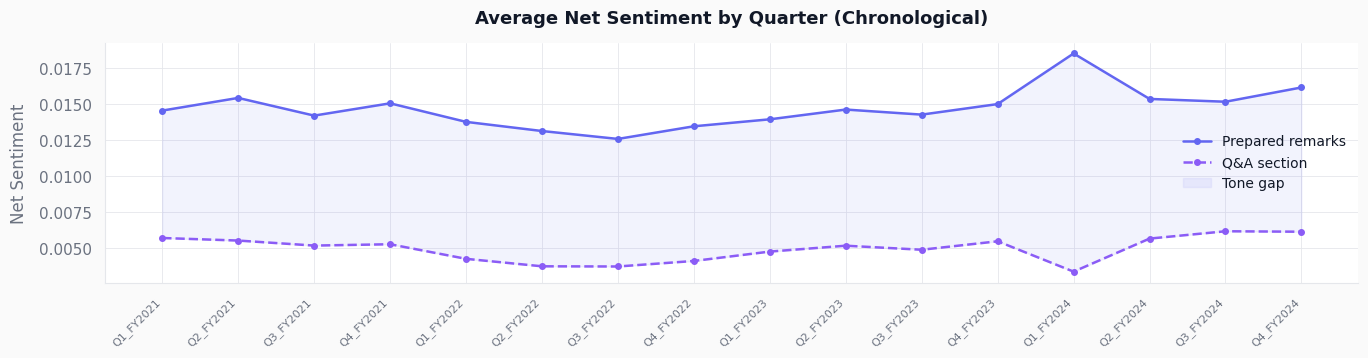

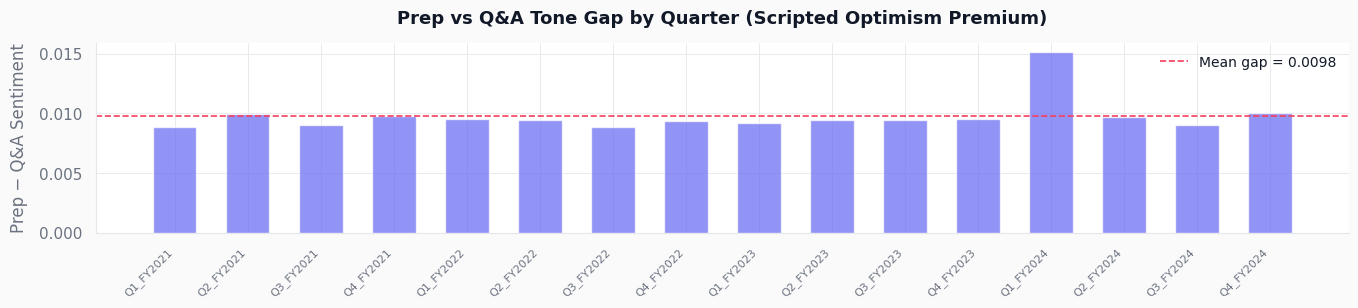

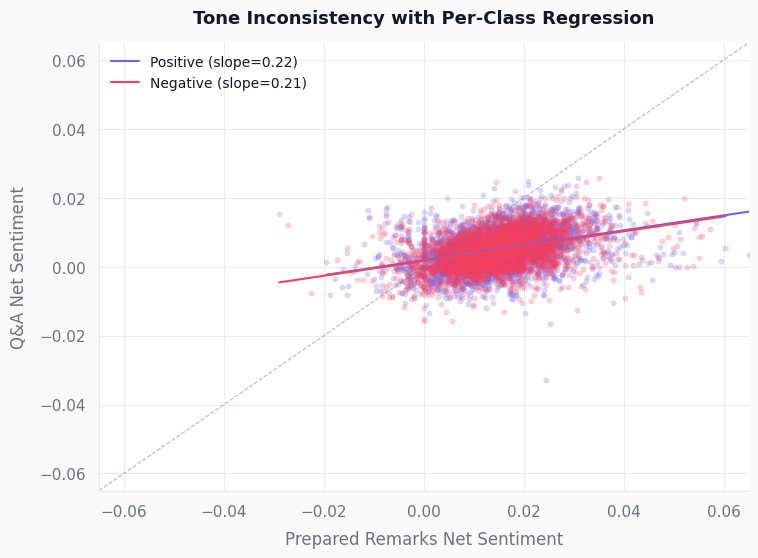

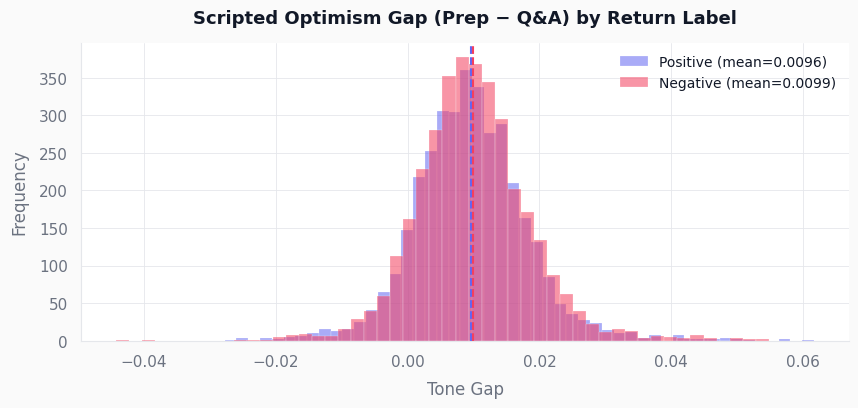

Tone gap t-test:  t=-1.5442  p=0.1226
  Positive returns mean gap: 0.00959
  Negative returns mean gap: 0.00991


In [ ]:
# ── Sort quarters chronologically ────────────────────────────────────────────
def quarter_sort_key(q):
    # "Q2_FY2023" → (2023, 2)
    parts = q.split('_')
    qnum = int(parts[0][1:])
    year = int(parts[1][2:])
    return (year, qnum)

quarter_order = sorted(pdf['quarter'].unique(), key=quarter_sort_key)
quarterly = pdf.groupby('quarter')[['prep_net_sentiment', 'qa_net_sentiment']].mean()
quarterly = quarterly.loc[quarter_order]

fig, ax = card_fig(14, 4)
ax.plot(range(len(quarterly)), quarterly['prep_net_sentiment'],
        color=BLUE, linewidth=1.8, marker='o', markersize=4, label='Prepared remarks')
ax.plot(range(len(quarterly)), quarterly['qa_net_sentiment'],
        color=PURPLE, linewidth=1.8, marker='o', markersize=4,
        linestyle='--', label='Q&A section')
ax.fill_between(range(len(quarterly)),
                quarterly['prep_net_sentiment'],
                quarterly['qa_net_sentiment'],
                alpha=0.08, color=BLUE, label='Tone gap')
ax.set_xticks(range(len(quarterly)))
ax.set_xticklabels(quarterly.index, rotation=45, ha='right', fontsize=8)
ax.set_title('Average Net Sentiment by Quarter (Chronological)')
ax.set_ylabel('Net Sentiment')
ax.legend(frameon=False, fontsize=10)
plt.tight_layout(pad=2)
plt.show()


# ── Plot the tone gap over time ──────────────────────────────────────────────
quarterly['tone_gap'] = quarterly['prep_net_sentiment'] - quarterly['qa_net_sentiment']

fig, ax = card_fig(14, 3.5)
ax.bar(range(len(quarterly)), quarterly['tone_gap'],
       color=BLUE, alpha=0.7, width=0.6)
ax.axhline(quarterly['tone_gap'].mean(), color=NEG_COLOR,
           linewidth=1.2, linestyle='--',
           label=f"Mean gap = {quarterly['tone_gap'].mean():.4f}")
ax.set_xticks(range(len(quarterly)))
ax.set_xticklabels(quarterly.index, rotation=45, ha='right', fontsize=8)
ax.set_title('Prep vs Q&A Tone Gap by Quarter (Scripted Optimism Premium)')
ax.set_ylabel('Prep − Q&A Sentiment')
ax.legend(frameon=False, fontsize=10)
plt.tight_layout(pad=2)
plt.show()


# ── Compare prepared remarks and Q&A tone by return label ────────────────────
fig, ax = card_fig(8, 6)

for label, color in [('positive', POS_COLOR), ('negative', NEG_COLOR)]:
    sub = pdf[pdf['return_label'] == label]
    x, y = sub['prep_net_sentiment'], sub['qa_net_sentiment']

    ax.scatter(x, y, c=color, alpha=0.25, s=18, linewidths=0)

    # Add one trend line per return label
    m, b = np.polyfit(x, y, 1)
    xr = np.linspace(x.min(), x.max(), 100)
    ax.plot(xr, m * xr + b, color=color, linewidth=1.5,
            label=f'{label.capitalize()} (slope={m:.2f})')

# Reference line where prepared remarks and Q&A sentiment are equal
lim = 0.065
ax.plot([-lim, lim], [-lim, lim], color=TEXT_MUTED,
        linewidth=0.8, linestyle='--', alpha=0.5)
ax.set_xlim(-lim, lim)
ax.set_ylim(-lim, lim)
ax.set_title('Tone Inconsistency with Per-Class Regression')
ax.set_xlabel('Prepared Remarks Net Sentiment')
ax.set_ylabel('Q&A Net Sentiment')
ax.legend(frameon=False, fontsize=10)
plt.tight_layout(pad=2)
plt.show()


# ── Tone gap distribution by return label ────────────────────────────────────
pdf['tone_gap'] = pdf['prep_net_sentiment'] - pdf['qa_net_sentiment']

fig, ax = card_fig(9, 4.5)
for label, color in [('positive', POS_COLOR), ('negative', NEG_COLOR)]:
    vals = pdf[pdf['return_label'] == label]['tone_gap']
    ax.hist(vals, bins=50, color=color, alpha=0.55,
            edgecolor='white', linewidth=0.3,
            label=f'{label.capitalize()} (mean={vals.mean():.4f})')
    ax.axvline(vals.mean(), color=color, linewidth=1.5, linestyle='--')

ax.set_title('Scripted Optimism Gap (Prep − Q&A) by Return Label')
ax.set_xlabel('Tone Gap')
ax.set_ylabel('Frequency')
ax.legend(frameon=False, fontsize=10)
plt.tight_layout(pad=2)
plt.show()

# significance test on tone gap
from scipy import stats
pos_gap = pdf[pdf['return_label'] == 'positive']['tone_gap']
neg_gap = pdf[pdf['return_label'] == 'negative']['tone_gap']
t, p = stats.ttest_ind(pos_gap, neg_gap)
print(f"Tone gap t-test:  t={t:.4f}  p={p:.4f}")
print(f"  Positive returns mean gap: {pos_gap.mean():.5f}")
print(f"  Negative returns mean gap: {neg_gap.mean():.5f}")

In [ ]:
from scipy import stats
import numpy as np

print("Statistical Significance of Prep vs. Q&A Net Sentiment by Quarter:")
print(f"{'Quarter':<12} {'Mean Prep':>12} {'Mean Q&A':>12} {'T-statistic':>15} {'P-value':>10} {'Significant (α=0.05)':>25}")
print("-" * 80)

# Get unique quarters and sort them chronologically
def quarter_sort_key(q):
    parts = q.split('_')
    qnum = int(parts[0][1:])
    year = int(parts[1][2:])
    return (year, qnum)

quarter_order = sorted(pdf['quarter'].unique(), key=quarter_sort_key)

results = []
for q in quarter_order:
    quarter_data = pdf[pdf['quarter'] == q]
    if len(quarter_data) > 1: # Need at least 2 samples for t-test
        prep_sentiment = quarter_data['prep_net_sentiment']
        qa_sentiment = quarter_data['qa_net_sentiment']

        # Perform paired t-test
        t_statistic, p_value = stats.ttest_rel(prep_sentiment, qa_sentiment)

        mean_prep = prep_sentiment.mean()
        mean_qa = qa_sentiment.mean()
        is_significant = 'Yes' if p_value < 0.05 else 'No'

        print(f"{q:<12} {mean_prep:>12.4f} {mean_qa:>12.4f} {t_statistic:>15.3f} {p_value:>10.4f} {is_significant:>25}")
        results.append({
            'quarter': q,
            'mean_prep': mean_prep,
            'mean_qa': mean_qa,
            't_statistic': t_statistic,
            'p_value': p_value,
            'significant': is_significant
        })
    else:
        print(f"{q:<12} {'N/A':>12} {'N/A':>12} {'N/A':>15} {'N/A':>10} {'Not enough data':>25}")

# Optionally convert results to a DataFrame for easier analysis
# results_df = pd.DataFrame(results)
# display(results_df)


Statistical Significance of Prep vs. Q&A Net Sentiment by Quarter:
Quarter         Mean Prep     Mean Q&A     T-statistic    P-value      Significant (α=0.05)
--------------------------------------------------------------------------------
Q1_FY2021          0.0145       0.0057          22.089     0.0000                       Yes
Q2_FY2021          0.0154       0.0055          24.055     0.0000                       Yes
Q3_FY2021          0.0142       0.0052          23.031     0.0000                       Yes
Q4_FY2021          0.0150       0.0053          27.959     0.0000                       Yes
Q1_FY2022          0.0138       0.0042          25.382     0.0000                       Yes
Q2_FY2022          0.0131       0.0037          23.603     0.0000                       Yes
Q3_FY2022          0.0126       0.0037          24.574     0.0000                       Yes
Q4_FY2022          0.0135       0.0041          24.910     0.0000                       Yes
Q1_FY2023          0.013

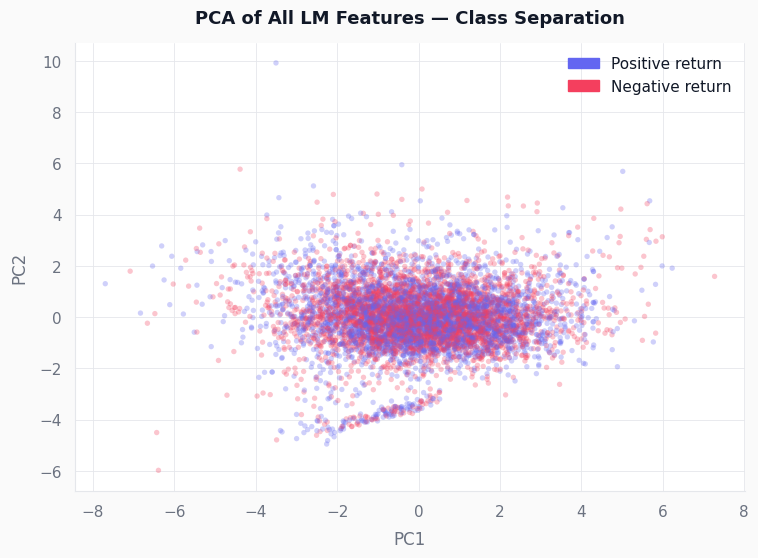

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Use the LM sentiment columns for a PCA check
feature_cols = [
    'prep_net_sentiment', 'qa_net_sentiment',
    'prep_positive_score', 'qa_positive_score',
    'prep_negative_score', 'qa_negative_score',
    'prep_uncertainty_score', 'qa_uncertainty_score',
    'prep_litigious_score', 'qa_litigious_score'
]

# Keep only columns that are available in the current notebook state
feature_cols = [col for col in feature_cols if col in pdf.columns]

X = pdf[feature_cols].dropna()

# Keep the original index so labels still line up after dropping missing rows
original_index = X.index

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA
X_pca = PCA(n_components=2).fit_transform(X_scaled)

fig, ax = card_fig(8, 6)
# Ensure 'return_label' aligns with the PCA data after dropna
colors_for_pca = pdf.loc[original_index, 'return_label'].map({True: POS_COLOR, False: NEG_COLOR})
colors_for_pca = pdf.loc[original_index, 'return_label'].map({'positive': POS_COLOR, 'negative': NEG_COLOR})

ax.scatter(X_pca[:, 0], X_pca[:, 1], c=colors_for_pca, alpha=0.3, s=15, linewidths=0)
ax.set_title('PCA of All LM Features — Class Separation')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
legend_handles = [
    mpatches.Patch(color=POS_COLOR, label='Positive return'),
    mpatches.Patch(color=NEG_COLOR, label='Negative return'),
]
ax.legend(handles=legend_handles, frameon=False)
plt.tight_layout(pad=2)
plt.show()